In [ ]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath(".."))

# Plotting settings
sns.set_theme(style="whitegrid", font_scale=1.05)

FIGSIZE_MAIN = (8, 5)
FIGSIZE_PANEL = (15, 12)
FIGSIZE_HEATMAP = (14, 11)

COLOR_NEGATIVE = "#4C72B0"   
COLOR_POSITIVE = "#C44E52"   

CHAGAS_PALETTE = {
    "Negative": COLOR_NEGATIVE,
    "Positive": COLOR_POSITIVE
}


In [ ]:
df = pd.read_csv("new_df.csv")

print("Feature table shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df["Chagas"] = df["chagas"].map({
    0: "Negative",
    1: "Positive"
})

display(df.head())


Feature table shape: (342142, 42)

Columns:
['peak_count_mean', 'peak_count_std', 'rr_mean_mean', 'rr_mean_std', 'rr_std_mean', 'rr_std_std', 'hrv_rmssd_mean', 'hrv_rmssd_std', 'total_power_mean', 'total_power_std', 'dominant_frequency_mean', 'dominant_frequency_std', 'energy_approx_mean', 'energy_approx_std', 'energy_detail_1_mean', 'energy_detail_1_std', 'energy_detail_2_mean', 'energy_detail_2_std', 'energy_detail_3_mean', 'energy_detail_3_std', 'energy_detail_4_mean', 'energy_detail_4_std', 'energy_detail_5_mean', 'energy_detail_5_std', 'pr_interval', 'qrs_duration', 'qt_interval', 'sdnn', 'pnn50', 'interval_lead_idx', 'n_usable_leads', 'exam_id', 'patient_id', 'chagas', 'age', 'is_male', 'RBBB', '1dAVb', 'LBBB', 'AF', 'SB', 'ST']


,peak_count_mean,peak_count_std,rr_mean_mean,rr_mean_std,rr_std_mean,rr_std_std,hrv_rmssd_mean,hrv_rmssd_std,total_power_mean,total_power_std,...,chagas,age,is_male,RBBB,1dAVb,LBBB,AF,SB,ST,Chagas
0,9.000000,0.000000,780.494792,0.160915,27.159244,0.458671,34.662643,0.798513,0.943378,0.014502,...,0,38,True,False,False,False,False,False,False,Negative
1,9.000000,0.000000,806.979167,1.964409,27.245241,4.376813,20.814727,12.313813,0.942810,0.026628,...,0,73,True,False,False,False,False,False,False,Negative
2,7.166667,0.389249,934.667659,53.227978,261.084499,28.364917,507.463123,61.334420,1.030292,0.053888,...,0,67,True,False,False,False,True,False,False,Negative
3,10.250000,0.452267,969.136574,44.682325,76.053517,79.027230,96.236002,90.818974,0.825276,0.028905,...,0,41,True,False,False,False,False,False,False,Negative
4,17.000000,0.000000,591.536458,1.042495,7.179197,9.447710,10.303553,16.529931,1.027969,0.040922,...,0,73,True,False,False,False,False,False,False,Negative


In [ ]:
class_distribution = (
    df["chagas"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("proportion")
    .reset_index()
    .rename(columns={"index": "chagas"})
    .sort_values("chagas")
)

display(class_distribution)

,chagas,proportion
0,0,98.08296
1,1,1.91704


\begin{table}
\caption{Distribution of Chagas status in the final feature table}
\label{tab:final_chagas_distribution}
\begin{tabular}{rr}
\toprule
chagas & proportion \\
\midrule
0 & 98.08 \\
1 & 1.92 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
exclude_cols = [
    "exam_id",
    "patient_id",
    "chagas",
    "Chagas",
    "age",
    "is_male",
    "RBBB",
    "LBBB",
    "1dAVb",
    "AF",
    "SB",
    "ST",
    "normal_ecg",
    "interval_lead_idx",
    "n_usable_leads",
]

exclude_cols = [col for col in exclude_cols if col in df.columns]

feature_cols = [
    col for col in df.select_dtypes(include=np.number).columns
    if col not in exclude_cols
]

print("Number of extracted numerical features:", len(feature_cols))
print(feature_cols)


Number of extracted numerical features: 29
['peak_count_mean', 'peak_count_std', 'rr_mean_mean', 'rr_mean_std', 'rr_std_mean', 'rr_std_std', 'hrv_rmssd_mean', 'hrv_rmssd_std', 'total_power_mean', 'total_power_std', 'dominant_frequency_mean', 'dominant_frequency_std', 'energy_approx_mean', 'energy_approx_std', 'energy_detail_1_mean', 'energy_detail_1_std', 'energy_detail_2_mean', 'energy_detail_2_std', 'energy_detail_3_mean', 'energy_detail_3_std', 'energy_detail_4_mean', 'energy_detail_4_std', 'energy_detail_5_mean', 'energy_detail_5_std', 'pr_interval', 'qrs_duration', 'qt_interval', 'sdnn', 'pnn50']


In [ ]:
#Discriptive statistics for numerical features
feature_summary = (
    df[feature_cols]
    .describe()
    .T
    .round(3)
)

display(feature_summary)


,count,mean,std,min,25%,50%,75%,max
peak_count_mean,342142.0,9.839,2.595,0.000,8.000,9.167,11.167,31.667
peak_count_std,342142.0,0.284,0.507,0.000,0.000,0.000,0.389,14.702
rr_mean_mean,342129.0,853.077,158.836,307.822,747.083,846.488,950.298,4893.233
rr_mean_std,342124.0,23.801,66.831,0.000,0.176,1.732,25.039,3445.010
rr_std_mean,342129.0,51.150,59.347,0.000,15.976,30.256,61.047,2079.568
rr_std_std,342124.0,30.274,51.085,0.000,0.811,8.761,42.818,1403.368
hrv_rmssd_mean,342122.0,70.118,94.660,0.759,19.244,36.772,78.511,4119.735
hrv_rmssd_std,342064.0,44.137,81.564,0.000,1.507,15.469,54.882,2811.634
total_power_mean,342142.0,0.903,0.119,0.008,0.844,0.922,0.980,1.366
total_power_std,342142.0,0.070,0.058,0.000,0.032,0.053,0.088,0.632


In [ ]:
#Selected fetaures for EDA
selected_features = [
    "peak_count_mean",
    "rr_mean_mean",
    "rr_std_mean",
    "hrv_rmssd_mean",
    "total_power_mean",
    "dominant_frequency_mean",
    "pr_interval",
    "qrs_duration",
    "qt_interval",
    "sdnn",
    "pnn50",
]

selected_features = [col for col in selected_features if col in df.columns]

selected_feature_summary = (
    df[selected_features]
    .describe()
    .T[["count", "mean", "50%", "max"]]
    .rename(columns={
        "count": "Count",
        "mean": "Mean",
        "50%": "Median",
        "max": "Max"
    })
    .round(3)
)

display(selected_feature_summary)

,Count,Mean,Median,Max
peak_count_mean,342142.0,9.839,9.167,31.667
rr_mean_mean,342129.0,853.077,846.488,4893.233
rr_std_mean,342129.0,51.150,30.256,2079.568
hrv_rmssd_mean,342122.0,70.118,36.772,4119.735
total_power_mean,342142.0,0.903,0.922,1.366
dominant_frequency_mean,342142.0,4.092,3.776,32.812
pr_interval,341136.0,114.978,113.846,742.500
qrs_duration,340459.0,120.127,114.500,504.167
qt_interval,340498.0,367.971,372.344,995.000
sdnn,342127.0,69.279,35.791,2271.677


\begin{table}
\caption{Selected descriptive statistics of extracted ECG features}
\label{tab:selected_feature_stats}
\begin{tabular}{lrrrr}
\toprule
 & Count & Mean & Median & Max \\
\midrule
peak_count_mean & 342142.000 & 9.839 & 9.167 & 31.667 \\
rr_mean_mean & 342129.000 & 853.077 & 846.488 & 4893.233 \\
rr_std_mean & 342129.000 & 51.150 & 30.256 & 2079.568 \\
hrv_rmssd_mean & 342122.000 & 70.118 & 36.772 & 4119.735 \\
total_power_mean & 342142.000 & 0.903 & 0.922 & 1.366 \\
dominant_frequency_mean & 342142.000 & 4.092 & 3.776 & 32.812 \\
pr_interval & 341136.000 & 114.978 & 113.846 & 742.500 \\
qrs_duration & 340459.000 & 120.127 & 114.500 & 504.167 \\
qt_interval & 340498.000 & 367.971 & 372.344 & 995.000 \\
sdnn & 342127.000 & 69.279 & 35.791 & 2271.677 \\
pnn50 & 342127.000 & 22.377 & 11.613 & 100.000 \\
\bottomrule
\end{tabular}
\end{table}



In [ ]:
# Missing values analysis
missing = df[feature_cols].isna().sum()
missing = missing[missing > 0]

missing_df = pd.DataFrame({
    "Feature": missing.index,
    "Missing values": missing.values,
    "Missing proportion (%)": missing.values / len(df) * 100
})

missing_df = (
    missing_df
    .sort_values("Missing values", ascending=False)
    .reset_index(drop=True)
)

display(missing_df)


,Feature,Missing values,Missing proportion (%)
0,qrs_duration,1683,0.491901
1,qt_interval,1644,0.480502
2,pr_interval,1006,0.294030
3,hrv_rmssd_std,78,0.022798
4,hrv_rmssd_mean,20,0.005846
5,rr_mean_std,18,0.005261
6,rr_std_std,18,0.005261
7,sdnn,15,0.004384
8,pnn50,15,0.004384
9,rr_std_mean,13,0.003800


\begin{table}
\caption{Missing values in extracted ECG features}
\label{tab:feature_missing_values}
\begin{tabular}{lrr}
\toprule
Feature & Missing values & Missing proportion (%) \\
\midrule
qrs_duration & 1683 & 0.492 \\
qt_interval & 1644 & 0.481 \\
pr_interval & 1006 & 0.294 \\
hrv_rmssd_std & 78 & 0.023 \\
hrv_rmssd_mean & 20 & 0.006 \\
rr_mean_std & 18 & 0.005 \\
rr_std_std & 18 & 0.005 \\
sdnn & 15 & 0.004 \\
pnn50 & 15 & 0.004 \\
rr_std_mean & 13 & 0.004 \\
rr_mean_mean & 13 & 0.004 \\
\bottomrule
\end{tabular}
\end{table}



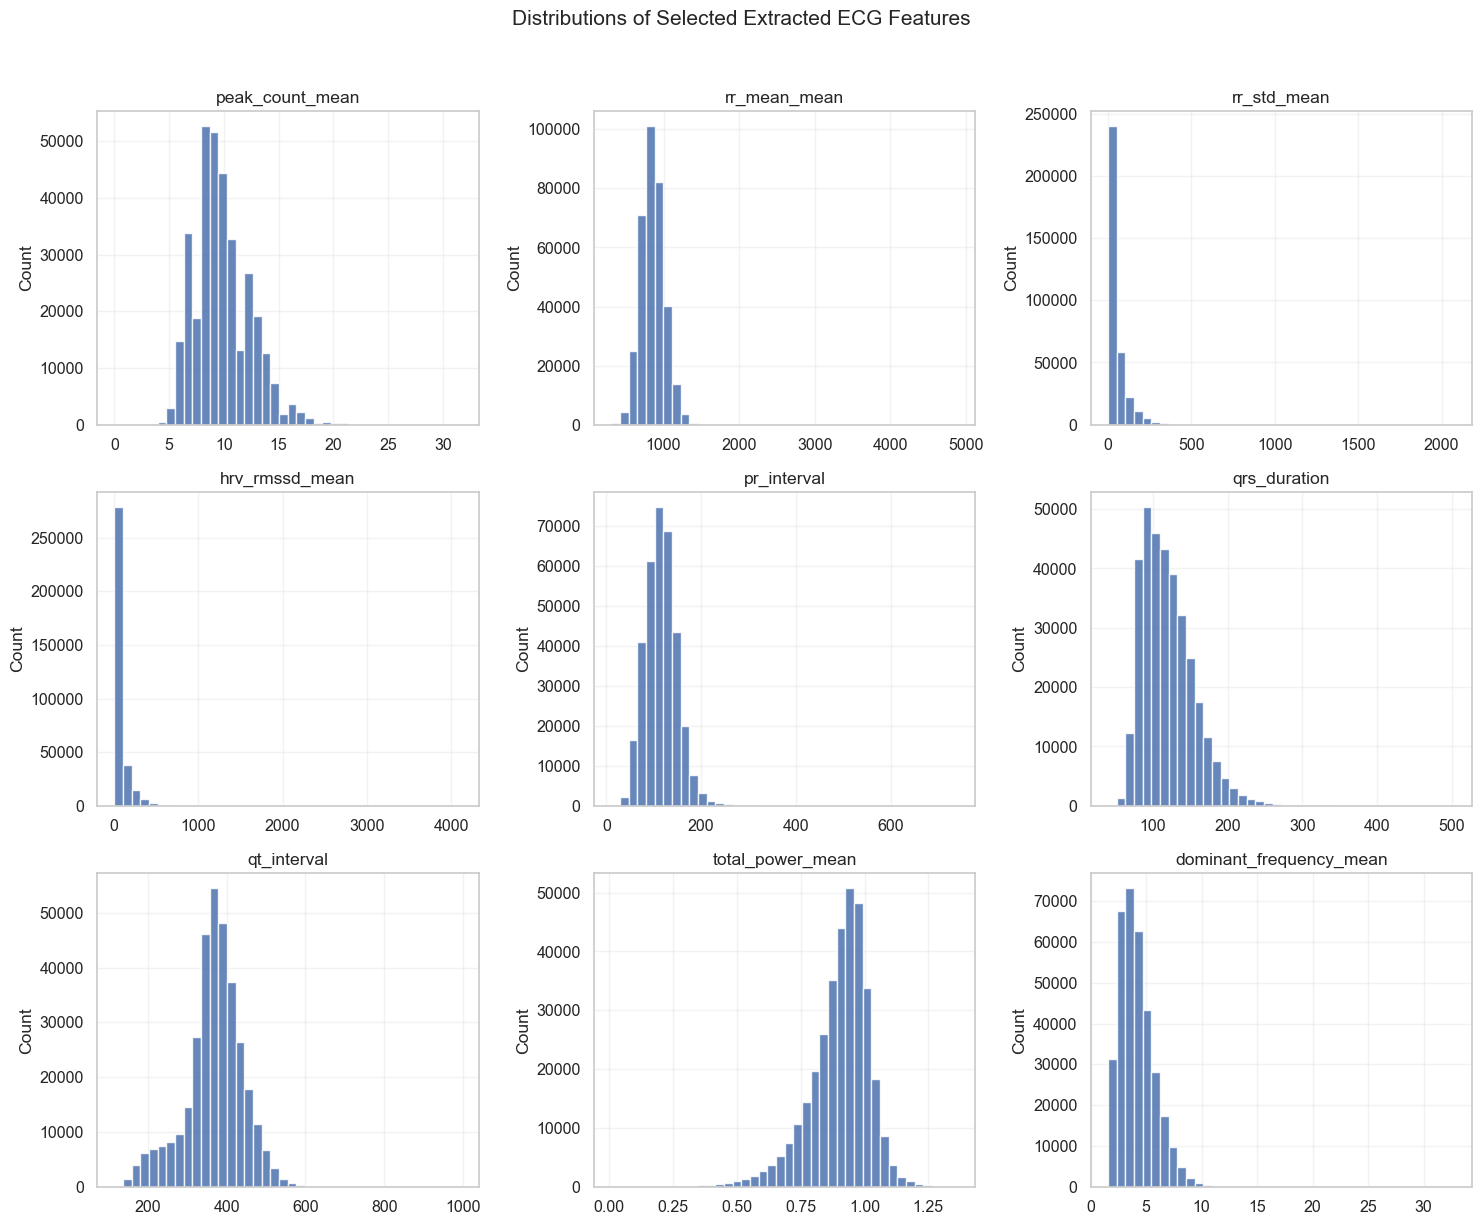

In [ ]:
# Distributions of selected features
hist_features = [
    "peak_count_mean",
    "rr_mean_mean",
    "rr_std_mean",
    "hrv_rmssd_mean",
    "pr_interval",
    "qrs_duration",
    "qt_interval",
    "total_power_mean",
    "dominant_frequency_mean",
]

hist_features = [col for col in hist_features if col in df.columns]

fig, axes = plt.subplots(3, 3, figsize=FIGSIZE_PANEL)
axes = axes.flatten()

for ax, feat in zip(axes, hist_features):

    values = df[feat].dropna()

    ax.hist(values, bins=40, color="#4C72B0", alpha=0.85)
    ax.set_title(feat)
    ax.set_xlabel("")
    ax.set_ylabel("Count")
    ax.grid(alpha=0.25)

for ax in axes[len(hist_features):]:
    ax.set_visible(False)

plt.suptitle(
    "Distributions of Selected Extracted ECG Features",
    y=1.02,
    fontsize=15
)

plt.tight_layout()
plt.show()

C:\Users\benas\AppData\Local\Temp\ipykernel_18776\3120337144.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\benas\AppData\Local\Temp\ipykernel_18776\3120337144.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\benas\AppData\Local\Temp\ipykernel_18776\3120337144.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\benas\AppData\Local\Temp\ipykernel_18776\3120337144.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `h

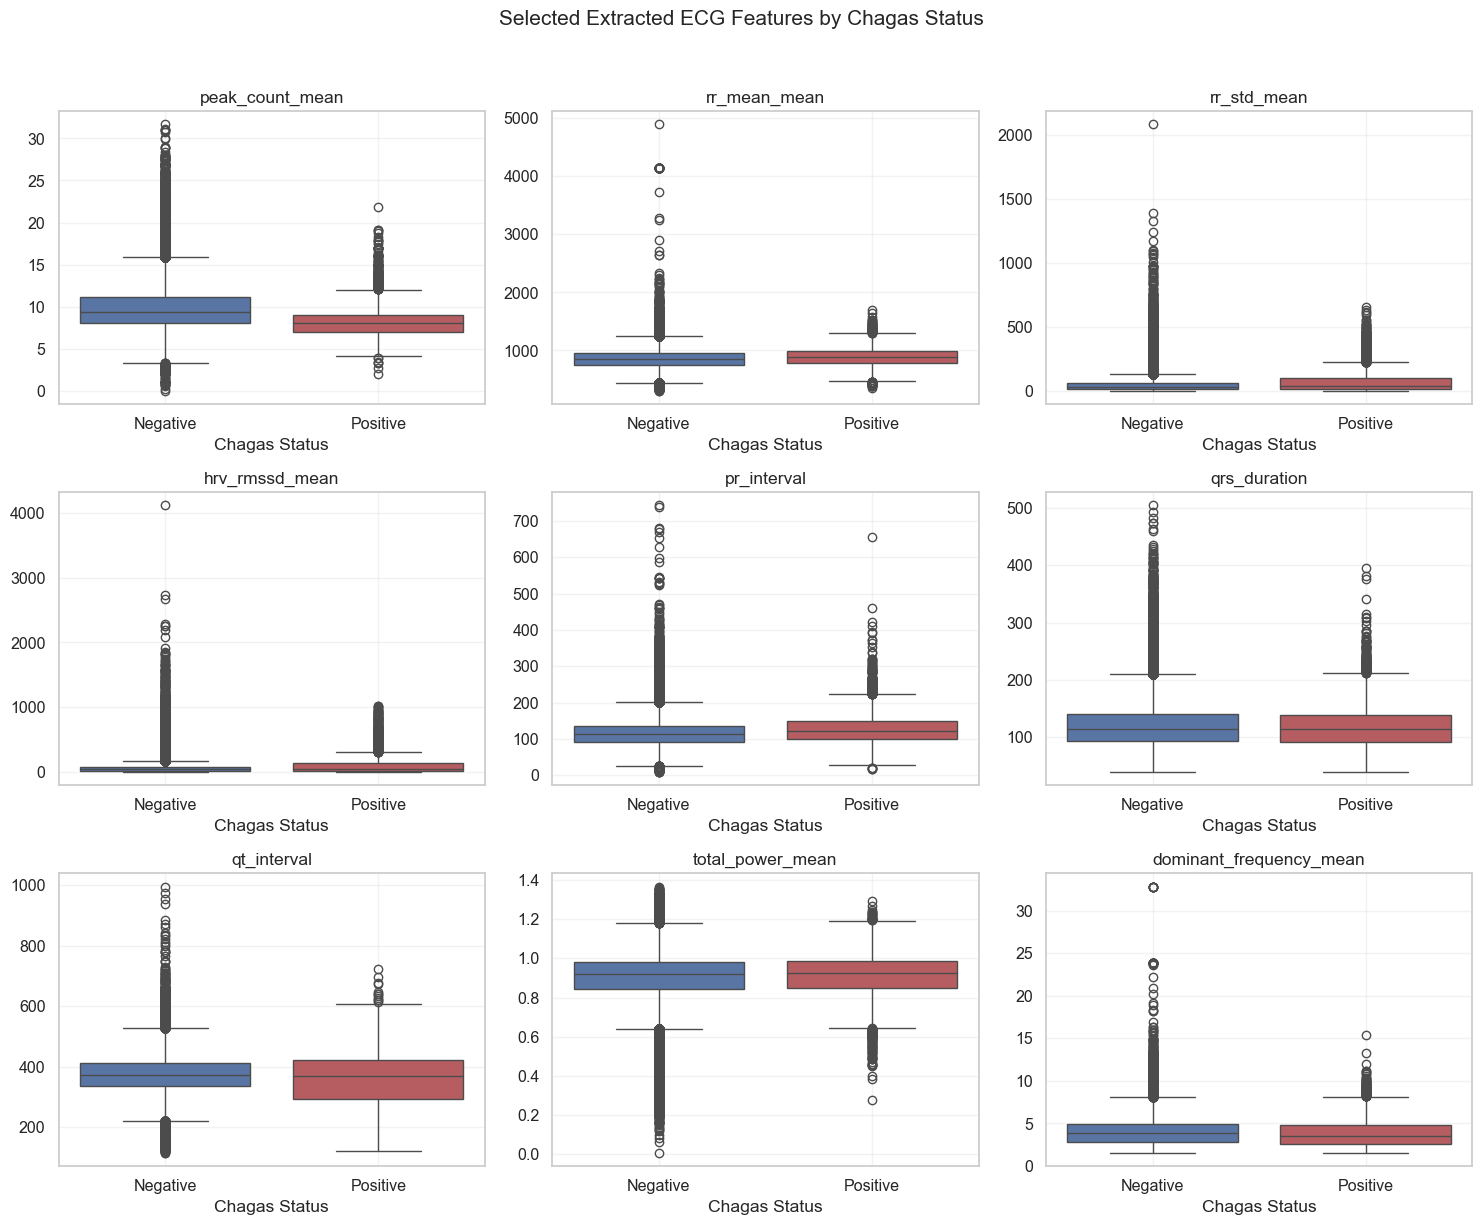

In [ ]:
# Boxplots of selected features by Chagas status
fig, axes = plt.subplots(3, 3, figsize=FIGSIZE_PANEL)
axes = axes.flatten()

for ax, feat in zip(axes, hist_features):

    sns.boxplot(
        data=df,
        x="Chagas",
        y=feat,
        order=["Negative", "Positive"],
        palette=CHAGAS_PALETTE,
        ax=ax,
        showfliers=True
    )

    ax.set_title(feat)
    ax.set_xlabel("Chagas Status")
    ax.set_ylabel("")
    ax.grid(alpha=0.25)

for ax in axes[len(hist_features):]:
    ax.set_visible(False)

plt.suptitle("Selected Extracted ECG Features by Chagas Status", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()


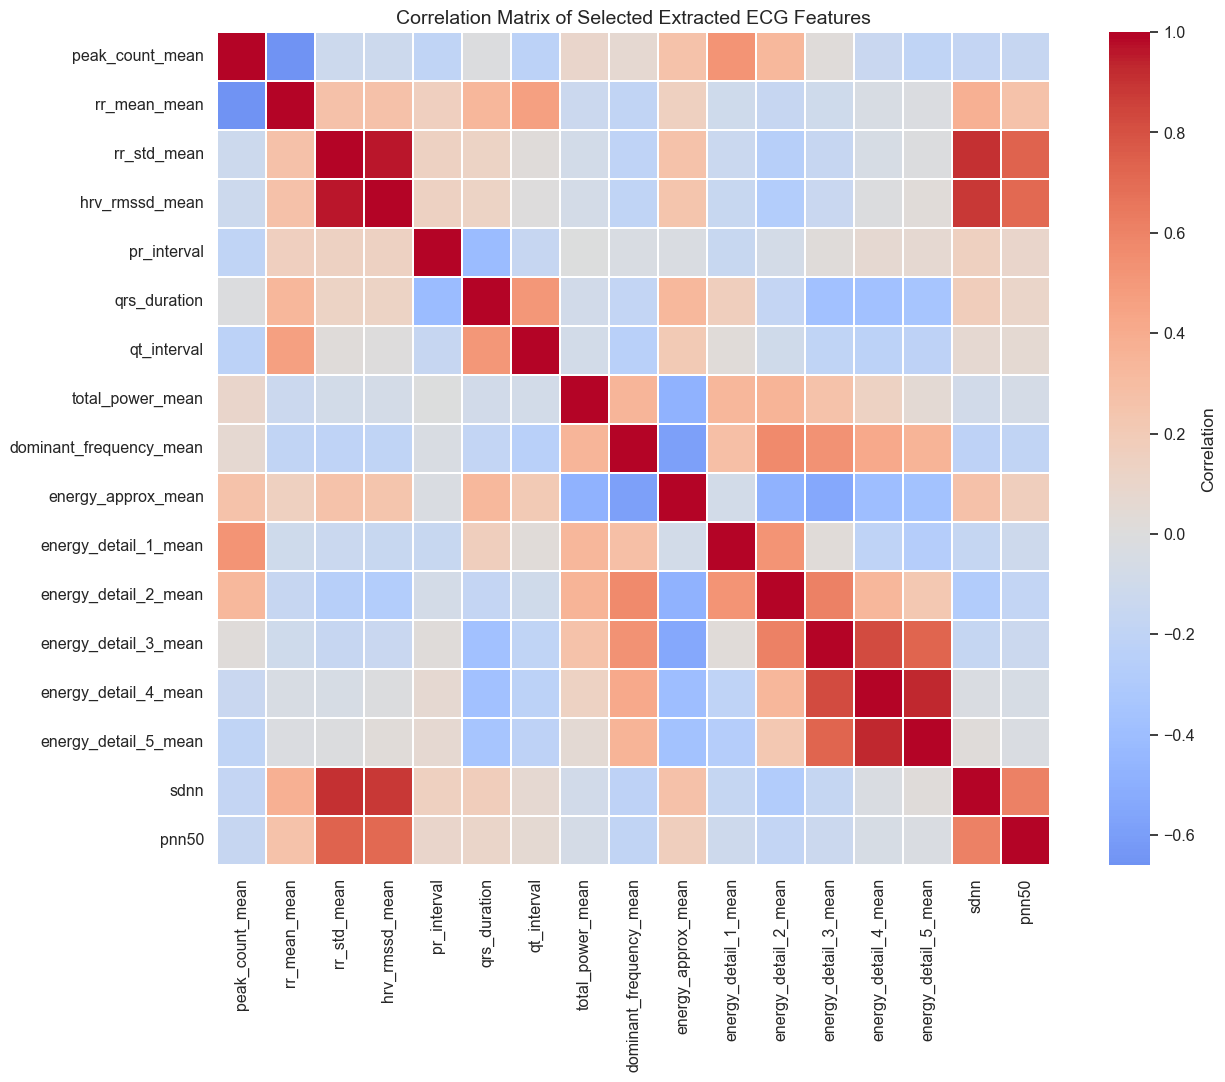

In [ ]:
# Correlation heatmap of selected extracted features
corr_features = [
    "peak_count_mean",
    "rr_mean_mean",
    "rr_std_mean",
    "hrv_rmssd_mean",
    "pr_interval",
    "qrs_duration",
    "qt_interval",
    "total_power_mean",
    "dominant_frequency_mean",
    "energy_approx_mean",
    "energy_detail_1_mean",
    "energy_detail_2_mean",
    "energy_detail_3_mean",
    "energy_detail_4_mean",
    "energy_detail_5_mean",
    "sdnn",
    "pnn50",
]

corr_features = [col for col in corr_features if col in df.columns]

corr = df[corr_features].corr()

plt.figure(figsize=FIGSIZE_HEATMAP)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"label": "Correlation"}
)

plt.title("Correlation Matrix of Selected Extracted ECG Features", fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
